In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords.words('english')
import string
string.punctuation
from nltk.stem.porter import PorterStemmer
from collections import Counter

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [4]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5330,ham,Dude im no longer a pisces. Im an aquarius now.,NaN,NaN,NaN
4024,ham,&lt;#&gt; in mca. But not conform.,NaN,NaN,NaN
5301,ham,At WHAT TIME should i come tomorrow,NaN,NaN,NaN
960,ham,U sure u can't take any sick time?,NaN,NaN,NaN
3410,ham,Only once then after ill obey all yours.,NaN,NaN,NaN


In [5]:
df.shape

(5572, 5)

# Steps followed
### Data cleaning
### EDA
### Text preprocessing
### Model building
### Evaluation
### Improvements
### Build a website
### Deployement of website

# **1. Data Cleaning**

In [6]:
# Drop last three columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [7]:
df.sample(5)

,v1,v2
4778,ham,O we cant see if we can join denis and mina? O...
5434,ham,Jesus armand really is trying to tell everybod...
3143,ham,"Haha I heard that, text me when you're around"
4031,ham,I'm very happy for you babe ! Woo hoo party on...
3941,ham,She's borderline but yeah whatever.


In [8]:
# Renaming the columns
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)
df.sample(5)


,target,text
659,spam,88800 and 89034 are premium phone services cal...
2049,ham,How much is blackberry bold2 in nigeria.
396,ham,Was actually sleeping and still might when u c...
3491,ham,I will reach office around &lt;DECIMAL&gt; . ...
4598,ham,Have you laid your airtel line to rest?


In [9]:
encoder= LabelEncoder()
df['target']=encoder.fit_transform(df['target'])


In [10]:
# checking missing values
df.isnull().sum()

,0
target,0
text,0


In [11]:
# checking duplicates values
df.duplicated().sum()

np.int64(403)

In [12]:
df = df.drop_duplicates(keep='first')

In [13]:
df.shape

(5169, 2)

# **2. EDA**

In [14]:
df['target'].value_counts()

,count
target,
0,4516
1,653


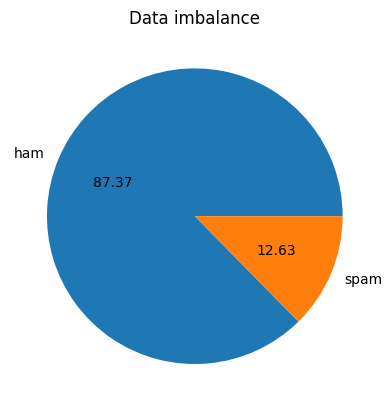

In [15]:
# Pie chart visualization
plt.pie(df['target'].value_counts(), labels=['ham','spam'], autopct="%0.2f")
plt.title('Data imbalance')
plt.show()

In [16]:
nltk.download('punkt') # Dependency
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [17]:
# Count chararcters
df['num_characters']=df['text'].apply(len)
df['num_characters']

,num_characters
0,111
1,29
2,155
3,49
4,61
...,...
5567,161
5568,37
5569,57
5570,125


In [18]:
# Number of words
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df['num_words']

,num_words
0,24
1,8
2,37
3,13
4,15
...,...
5567,35
5568,9
5569,15
5570,27


In [19]:
# Number of sentences
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df['num_sentences']


,num_sentences
0,2
1,2
2,2
3,1
4,1
...,...
5567,4
5568,1
5569,2
5570,1


In [20]:
df.head(5)

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [21]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [22]:
# Spam
df[df['target']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [23]:
# Not spam
df[df['target']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


<Axes: xlabel='num_characters', ylabel='Count'>

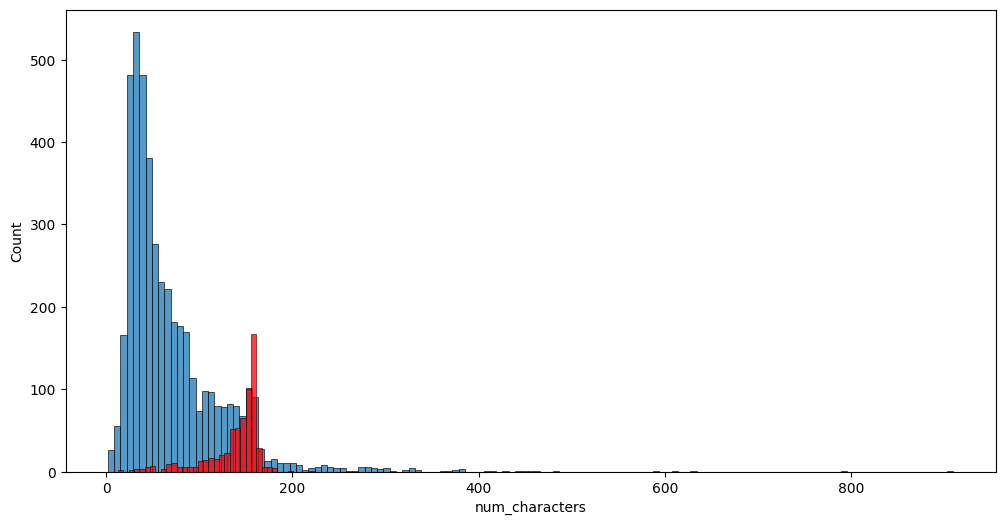

In [24]:
# Plotting histogram for number of characters
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']== 0]['num_characters']) # Not spam
sns.histplot(df[df['target']== 1]['num_characters'],color='red') # spam

<Axes: xlabel='num_words', ylabel='Count'>

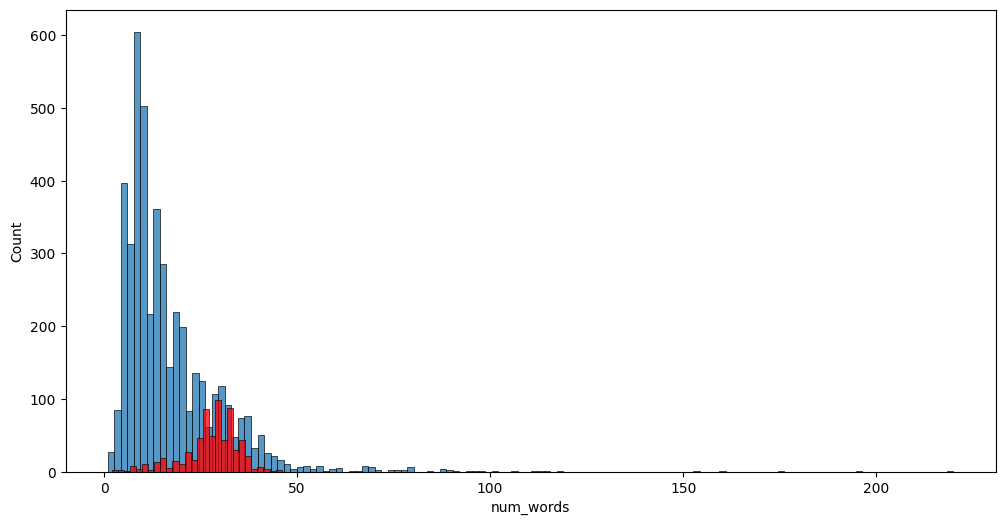

In [25]:
# For number of words
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']== 0]['num_words']) # Not spam
sns.histplot(df[df['target']== 1]['num_words'],color='red') # spam

<Axes: xlabel='num_sentences', ylabel='Count'>

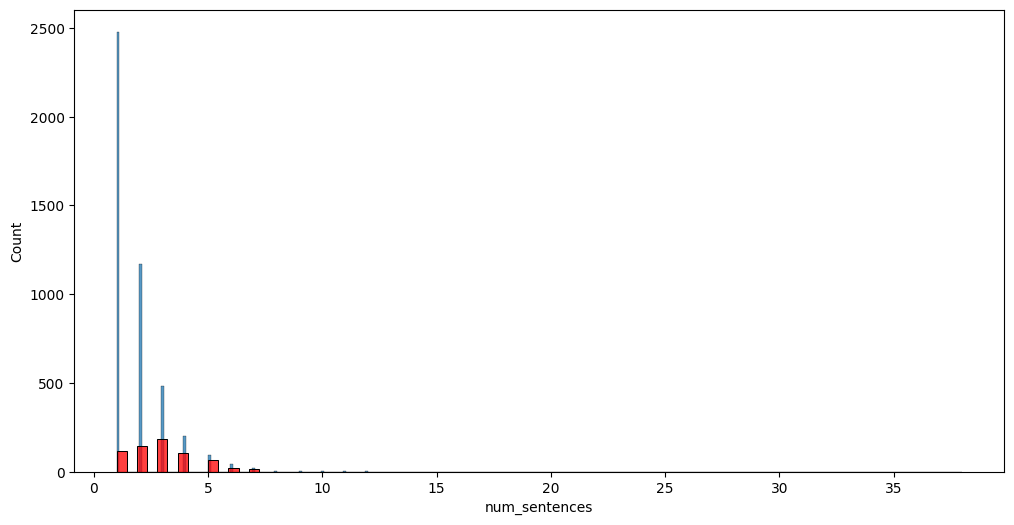

In [26]:
# For number of sentences
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']== 0]['num_sentences']) # Not spam
sns.histplot(df[df['target']== 1]['num_sentences'],color='red') # spam

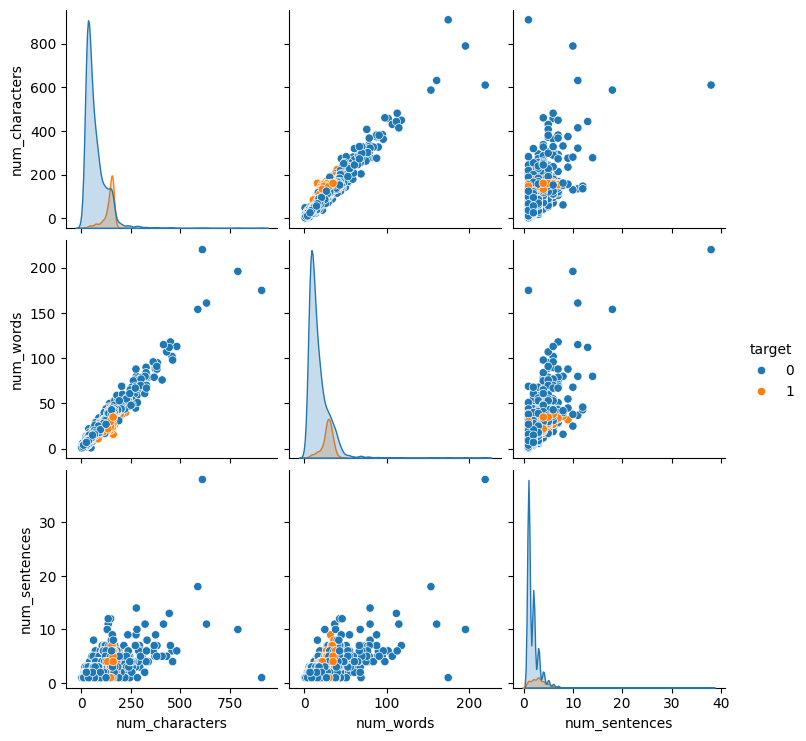

In [27]:
sns.pairplot(df,hue='target')

<Axes: >

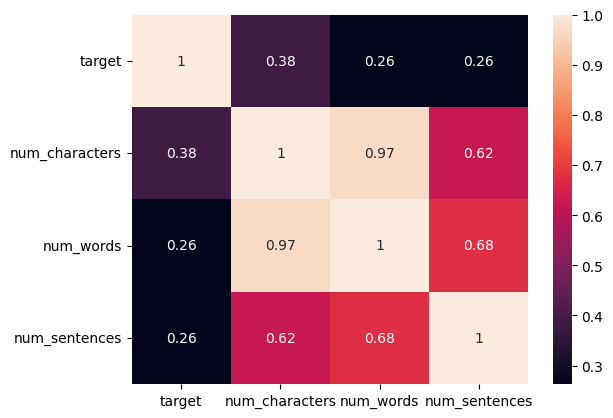

In [28]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

# **3. Data Preprocessing**
###

*   Lower case
*   Tokenization
*   Removing special characters
*   Removing stopping words and punctuation
*   Stemming





In [29]:
ps = PorterStemmer()
def transform_text(text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y=[]
  for i in text:
    if i.isalnum():
      y.append(i)


  text = y[:]
  y.clear()


  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    y.append(ps.stem(i))

  return " ".join(y)

In [30]:
transform_text("I loved the Lectures in Machine learing what about you???")

'love lectur machin lear'

In [31]:
transform_text('hi how are you is am are?')

'hi'

In [32]:
df['transformed_text'] = df['text'].apply(transform_text)

In [33]:
df.head(5)

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


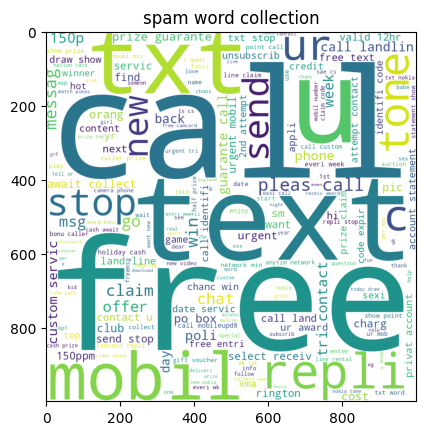

In [34]:
# Generating the word cloud for spam class
from wordcloud import WordCloud
wc = WordCloud(width=1000, height=1000, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['target']==1]['transformed_text'].astype(str).str.cat(sep=" "))
plt.title('spam word collection')
plt.imshow(spam_wc)

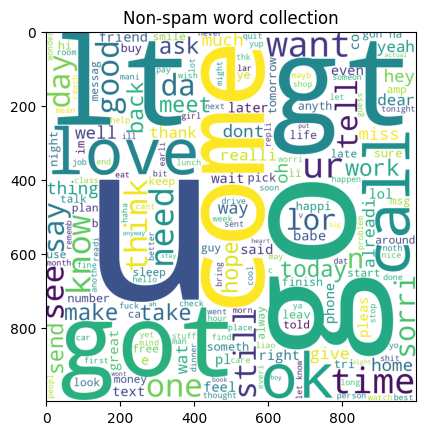

In [35]:
# Generating the word cloud for non spam class
from wordcloud import WordCloud
wc = WordCloud(width=1000, height=1000, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['target']==0]['transformed_text'].astype(str).str.cat(sep=" "))
plt.title('Non-spam word collection')
plt.imshow(spam_wc)

In [36]:
# Top 30 words in both class
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].tolist():
  for words in msg.split():
    spam_corpus.append(words)

In [37]:
len(spam_corpus)

9939

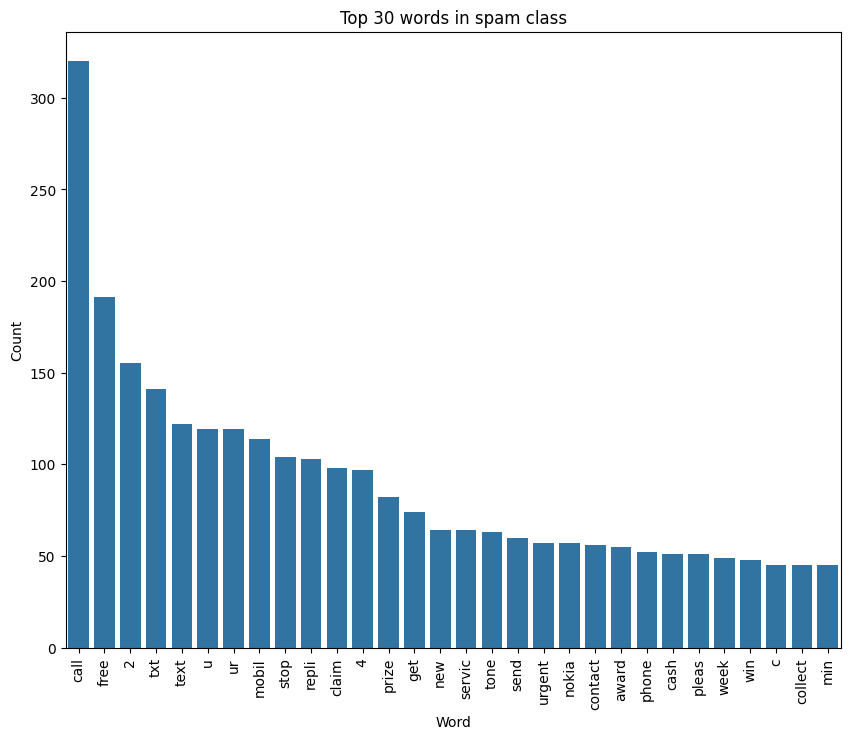

In [38]:
# Spam to 30 word plot
temp_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])
plt.figure(figsize=(10, 8))
sns.barplot(x='word', y='count', data=temp_df)
plt.title('Top 30 words in spam class')
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation='vertical')
plt.show()

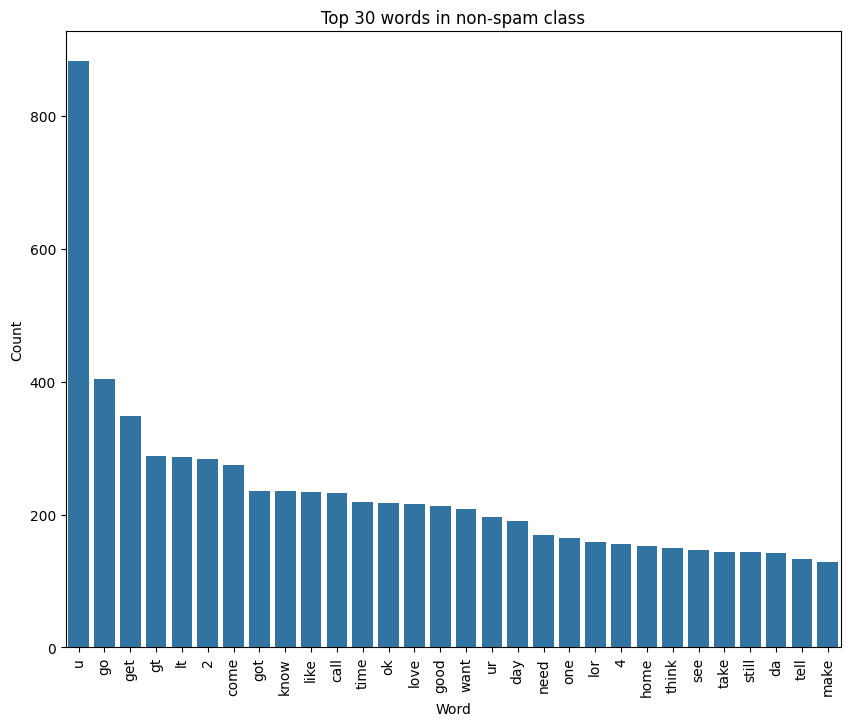

In [39]:
non_spam_corpus = []
for msg in df[df['target']==0]['transformed_text'].tolist():
  for words in msg.split():
    non_spam_corpus.append(words)
temp_df = pd.DataFrame(Counter(non_spam_corpus).most_common(30), columns=['word', 'count'])
plt.figure(figsize=(10, 8))
sns.barplot(x='word', y='count', data=temp_df)
plt.title('Top 30 words in non-spam class') # Changed title to non-spam
plt.xlabel('Word')
plt.ylabel('Count')
plt.xticks(rotation='vertical')
plt.show()

#**4. Model Building**

In [40]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [41]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [42]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [43]:
#appending the num_character col to X
X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

In [44]:
X

array([[  0.,   0.,   0., ...,   0.,   0., 111.],
       [  0.,   0.,   0., ...,   0.,   0.,  29.],
       [  0.,   0.,   0., ...,   0.,   0., 155.],
       ...,
       [  0.,   0.,   0., ...,   0.,   0.,  57.],
       [  0.,   0.,   0., ...,   0.,   0., 125.],
       [  0.,   0.,   0., ...,   0.,   0.,  26.]])

In [45]:
X.shape

(5169, 3001)

In [46]:
y = df['target'].values

In [47]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [50]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [51]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

# **GaussianNB Model**

In [52]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print("Accuracy_score:",accuracy_score(y_test, y_pred1))
print("precision_score:",precision_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))

Accuracy_score: 0.8945841392649904
precision_score: 0.5668202764976958
[[802  94]
 [ 15 123]]


# **MultinomialNB Model**

In [53]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print("Accuracy_score:",accuracy_score(y_test, y_pred2))
print("precision_score:",precision_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

Accuracy_score: 0.9729206963249516
precision_score: 0.9508196721311475
[[890   6]
 [ 22 116]]


# **BernoulliNB Model**

In [54]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print("Accuracy_score:",accuracy_score(y_test, y_pred3))
print("precision_score:",precision_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))

Accuracy_score: 0.9835589941972921
precision_score: 0.991869918699187
[[895   1]
 [ 16 122]]


In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [56]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [57]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [58]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [59]:
train_classifier(svc,X_train,y_train,X_test,y_test)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(0.8665377176015474, 0.0)

In [60]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


For  SVC
Accuracy -  0.8665377176015474
Precision -  0.0
For  KN
Accuracy -  0.8868471953578336
Precision -  0.8620689655172413
For  NB
Accuracy -  0.9729206963249516
Precision -  0.9508196721311475
For  DT
Accuracy -  0.9487427466150871
Precision -  0.897196261682243
For  LR
Accuracy -  0.9671179883945842
Precision -  0.9642857142857143
For  RF
Accuracy -  0.9729206963249516
Precision -  0.9824561403508771
For  AdaBoost
Accuracy -  0.9448742746615088
Precision -  0.8932038834951457
For  BgC
Accuracy -  0.960348162475822
Precision -  0.8646616541353384
For  ETC
Accuracy -  0.9806576402321083
Precision -  0.9836065573770492
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.971953578336557
Precision -  0.943089430894309


In [61]:
performance_df1 = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [62]:
performance_df1

,Algorithm,Accuracy,Precision
8,ETC,0.980658,0.983607
5,RF,0.972921,0.982456
4,LR,0.967118,0.964286
2,NB,0.972921,0.950820
10,xgb,0.971954,0.943089
9,GBDT,0.950677,0.930693
3,DT,0.948743,0.897196
6,AdaBoost,0.944874,0.893204
7,BgC,0.960348,0.864662
1,KN,0.886847,0.862069


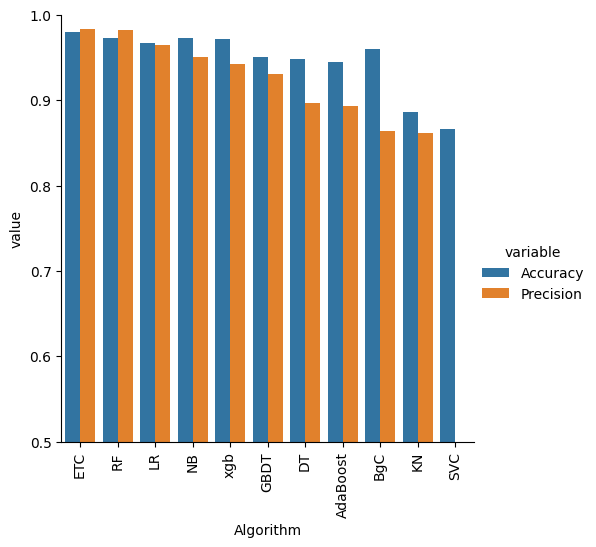

In [63]:
performance_df_melted = performance_df1.melt(id_vars=['Algorithm'], var_name='variable', value_name='value')
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df_melted, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [64]:
# model improve
# 1. Change the max_features parameter of TfIdf
# 2. Do the sacling
# 3. Test the chararcters based training
# 4. Then compare all the tuning

In [65]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)
new_df = performance_df1.merge(temp_df,on='Algorithm')
new_df_scaled = new_df.merge(temp_df,on='Algorithm')
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,ETC,0.980658,0.983607,0.980658,0.983607,0.980658,0.983607,0.980658,0.983607
1,RF,0.972921,0.982456,0.972921,0.982456,0.972921,0.982456,0.972921,0.982456
2,LR,0.967118,0.964286,0.967118,0.964286,0.967118,0.964286,0.967118,0.964286
3,NB,0.972921,0.950820,0.972921,0.950820,0.972921,0.950820,0.972921,0.950820
4,xgb,0.971954,0.943089,0.971954,0.943089,0.971954,0.943089,0.971954,0.943089
5,GBDT,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693
6,DT,0.948743,0.897196,0.948743,0.897196,0.948743,0.897196,0.948743,0.897196
7,AdaBoost,0.944874,0.893204,0.944874,0.893204,0.944874,0.893204,0.944874,0.893204
8,BgC,0.960348,0.864662,0.960348,0.864662,0.960348,0.864662,0.960348,0.864662
9,KN,0.886847,0.862069,0.886847,0.862069,0.886847,0.862069,0.886847,0.862069


# **Using different approach to reach best performance**

In [67]:
# 1. Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [68]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [69]:
voting.fit(X_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [78]:
y_pred = voting.predict(X_test)
print("Model:", voting)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Model: VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')
Accuracy 0.9748549323017408
Precision 1.0


In [71]:
# 2. Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [72]:
from sklearn.ensemble import StackingClassifier
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9729206963249516
Precision 0.9044117647058824


In [79]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))